# ROSMAP PCC : repeat-count DESeq2 with a 2-level TDP-43 split

In [1]:
# === 0. Setup =================================================================
options(warn = 1, scipen = 6, stringsAsFactors = FALSE)
t_start <- Sys.time()
log_msg <- function(msg) cat(sprintf("[%s] %s\n", format(Sys.time()), msg))
log_msg("=== ROSMAP PCC TDP-split pipeline starting ===")

[2026-05-28 15:20:11] === ROSMAP PCC TDP-split pipeline starting ===


In [2]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(here)
  library(powerjoin)
  library(qs)
  library(DESeq2)
  library(ashr)
  library(broom)
  library(broom.mixed)
  library(BiocParallel)
  library(RhpcBLASctl)
  library(conflicted)
  library(ggrepel)
  library(ggbeeswarm)
  library(ggnewscale)
  library(ggh4x)
  library(ggrastr)
  library(emmeans)
  library(pheatmap)
})

In [3]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(here)
  library(qs)
  library(DESeq2)
  library(ashr)
  library(broom)
  library(broom.mixed)
  library(BiocParallel)
  library(RhpcBLASctl)
  library(conflicted)
  library(ggrepel)
  library(ggbeeswarm)
  library(ggnewscale)
  library(ggh4x)
  library(ggrastr)
  library(emmeans)
  library(pheatmap)
  library(splines)
})

In [4]:
conflicts_prefer(
  dplyr::count, dplyr::filter, dplyr::select, dplyr::summarise,
  dplyr::mutate, dplyr::rename, dplyr::lag, dplyr::first, dplyr::last,
  dplyr::between, dplyr::slice, dplyr::collapse, dplyr::desc,
  dplyr::union, dplyr::intersect, dplyr::setdiff,
  .quiet = TRUE
)

In [5]:
library(tidyverse)

clinical <- read_csv("ROSMAP_clinical.csv")
assay    <- read_csv("ROSMAP_assay_rnaSeq_metadata.csv")

bam_ids <- tibble(sample_id = c("1012-PCC", "1051-PCC", "1089r-PCC")) %>%
  mutate(projid = str_extract(sample_id, "^\\d+") %>% as.integer(),
         is_replicate = str_detect(sample_id, "r-"))

Rows: 3584 Columns: 18
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): projid, Study, age_at_visit_max, age_first_ad_dx, age_death, indiv...
dbl (12): msex, educ, race, spanish, apoe_genotype, cts_mmse30_first_ad_dx, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3196 Columns: 13
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (9): specimenID, platform, libraryBatch, sequencingBatch, l

In [6]:
library(tidyverse)

#bam_ids  <- tibble(sample_id = clean_sample_id(bam_files$bam_path))  # all 545
biospec  <- read_csv("ROSMAP_biospecimen_metadata.csv",  guess_max = 50000)
clinical <- read_csv("ROSMAP_clinical.csv",              guess_max = 50000)
assay    <- read_csv("ROSMAP_assay_rnaSeq_metadata.csv", guess_max = 50000) %>%
  mutate(RIN = suppressWarnings(as.numeric(RIN)))

# Step 1: BAM → individualID via biospecimen.
# Try "Sample_<id>" first, fall back to bare "<id>" (a few rows use that).
spec_lookup <- biospec %>% select(specimenID, individualID, tissue, organ)


Rows: 13345 Columns: 20
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (12): individualID, specimenID, specimenIdSource, organ, tissue, Brodman...
dbl  (2): tissueWeight, tissueVolume
lgl  (6): fastingState, isPostMortem, samplingAgeUnits, visitNumber, exclude...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3584 Columns: 18
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): projid, Study, 

In [7]:
# ---- clean sample IDs from the gene_counts matrix ----
clean_sample_id <- function(x) {
  x <- basename(x)
  x <- sub("\\.bam$",   "", x)
  x <- sub("\\.final$", "", x)
  x
}
gene_counts <- qread("rosmap_pcc_full_gene_counts.qs")
bam_ids <- tibble(sample_id = clean_sample_id(colnames(gene_counts)))

dim(bam_ids)        # 545 x 1
head(bam_ids)

[1] 545   1

sample_id
<chr>
1012-PCC
1051-PCC
1089r-PCC
2000r-PCC
2002r-PCC
2003r-PCC


In [8]:
clean_sample_id <- function(x) {
  x <- basename(x)
  x <- sub("\\.bam$",                            "", x)
  x <- sub("\\.markdup$",                        "", x)
  x <- sub("\\.final$",                          "", x)
  x <- sub("\\.sorted$",                         "", x)
  x <- sub("\\.Aligned\\.sortedByCoord\\.out$",  "", x)
  x <- sub("_(redo|rerun)$",                     "", x)
  x
}

bam_samples <- tibble(sample_id = clean_sample_id(colnames(gene_counts)))
rosmap_meta_raw <- read_csv("rosmap_metadata_raw.csv")

Rows: 671 Columns: 44
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (20): sample_id, join_id, specimenID, individualID, cohort, Study, diagn...
dbl (19): projid, cogdx, dcfdx_lv, age_death_num, pmi, braak, cerad, apoe_ge...
lgl  (5): libraryBatch, rnaBatch, STMN2short, UNC13A-CE1, UNC13A-CE2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [9]:
pcc_meta <- bam_samples %>% left_join(rosmap_meta_raw, by = "sample_id")


In [10]:
cat("matched:", sum(!is.na(pcc_meta$individualID)),
    "| unmatched:", sum(is.na(pcc_meta$individualID)), "\n")

matched: 545 | unmatched: 0 


In [11]:
CLASSIF_PATH    <- "rosmap_classification.csv"
RM_RAW_PATH     <- "/n/scratch/users/r/rob6090/projects/tdp-43/scripts/analysis/final_dsRNA/repeatmasker_raw.csv"
REPEAT_QS_PATH  <- "amp-ad_full_PCC_repeat_counts_raw-fraction_AND_secondary_noMETA.qs"

In [12]:
OUT_DIR     <- "results_rosmap_pcc_tdp_split-full-plus_ctrl_run2"
PLOTS_DIR   <- file.path(OUT_DIR, "plots")
FAMILY_DIR  <- file.path(OUT_DIR, "per_family")
VOLCANO_DIR <- file.path(PLOTS_DIR, "volcanoes")

In [13]:
for (d in c(OUT_DIR, PLOTS_DIR, FAMILY_DIR, VOLCANO_DIR)) {
  dir.create(d, showWarnings = FALSE, recursive = TRUE)
}
log_msg(sprintf("All outputs will be written under %s/", OUT_DIR))

[2026-05-28 15:20:29] All outputs will be written under results_rosmap_pcc_tdp_split-full-plus_ctrl_run2/


In [14]:
rm_raw               <- read_csv(RM_RAW_PATH,  show_col_types = FALSE)

In [15]:
# === 2. Load inputs ===========================================================
log_msg("Loading inputs ...")
#rosmap_meta_raw      <- read_csv(META_PATH,    show_col_types = FALSE)
classif              <- read_csv(CLASSIF_PATH, show_col_types = FALSE)
#rm_raw               <- read_csv(RM_RAW_PATH,  show_col_types = FALSE)
rosmap_repeat_counts <- qread(REPEAT_QS_PATH)
log_msg(sprintf("rm_raw rows = %d ; count matrix = %d x %d",
                nrow(rm_raw),
                nrow(rosmap_repeat_counts$counts),
                ncol(rosmap_repeat_counts$counts)))

[2026-05-28 15:20:47] Loading inputs ...
[2026-05-28 15:21:56] rm_raw rows = 5448004 ; count matrix = 5448004 x 545


In [16]:
dim(rosmap_repeat_counts[["counts"]])

[1] 5448004     545

meta3 <- read_csv("rosmap_metadata_3groups.csv") %>%
  mutate(group = case_when(
    braak %in% c(0,1,2) & tdp43_status == "TDPneg"            ~ "Braak02_TDPneg",
    braak %in% c(3,4,5,6) & tdp43_status == "TDPneg"  ~ "Braak36_TDPneg_AD",
    braak %in% c(3,4,5,6) & tdp43_status == "TDPpos"  ~ "Braak36_TDPpos_AD"
  ) %>% factor(levels = c("Braak02_TDPneg", "Braak36_TDPneg_AD", "Braak36_TDPpos_AD")))

table(meta3$group)        # 59 / 115 / 69

In [17]:
 
# === 1. Paths and output directory ============================================
#META_PATH      <- "rosmap_metadata_3groups.csv"
RM_RAW_PATH    <- "/n/scratch/users/r/rob6090/projects/tdp-43/scripts/analysis/final_dsRNA/repeatmasker_raw.csv"
REPEAT_QS_PATH <- "amp-ad_full_PCC_repeat_counts_raw-fraction_AND_secondary_noMETA.qs"
 
OUT_DIR     <- "results_rosmap_pcc_3groups_ctrl_run2"
PLOTS_DIR   <- file.path(OUT_DIR, "plots")
FAMILY_DIR  <- file.path(OUT_DIR, "per_family")
VOLCANO_DIR <- file.path(PLOTS_DIR, "volcanoes")
 
for (d in c(OUT_DIR, PLOTS_DIR, FAMILY_DIR, VOLCANO_DIR)) {
  dir.create(d, showWarnings = FALSE, recursive = TRUE)
}
log_msg(sprintf("All outputs will be written under %s/", OUT_DIR))

[2026-05-28 15:21:56] All outputs will be written under results_rosmap_pcc_3groups_ctrl_run2/


In [18]:
# === 2. Load inputs ===========================================================
log_msg("Loading inputs ...")
#meta_raw             <- read_csv(META_PATH,   show_col_types = FALSE)
rm_raw               <- read_csv(RM_RAW_PATH, show_col_types = FALSE)
rosmap_repeat_counts <- qread(REPEAT_QS_PATH)
log_msg(sprintf("rm_raw rows = %d ; count matrix = %d x %d",
                nrow(rm_raw),
                nrow(rosmap_repeat_counts$counts),
                ncol(rosmap_repeat_counts$counts)))

[2026-05-28 15:21:56] Loading inputs ...
[2026-05-28 15:23:13] rm_raw rows = 5448004 ; count matrix = 5448004 x 545


In [19]:
dim(pcc_meta)

[1] 545  44

In [20]:
head(pcc_meta)

sample_id,join_id,specimenID,individualID,projid,cohort,Study,diagnosis,cogdx,dcfdx_lv,⋯,tdp43_status_low,n_expressed,STMN2short,UNC13A-CE1,UNC13A-CE2,class_low,class_high,tissue,organ,brain_region
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<chr>,<dbl>,<lgl>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>
1012-PCC,1012-PCC,Sample_1012-PCC,R9798367,51791453,ROSMAP_PCC,MAP,MCI,2,2,⋯,TDPneg,0,FALSE,FALSE,FALSE,negative,negative,posterior cingulate cortex,brain,PCC
1051-PCC,1051-PCC,Sample_1051-PCC,R5691943,69924281,ROSMAP_PCC,MAP,AD,4,4,⋯,TDPpos,1,TRUE,FALSE,FALSE,positive,negative,posterior cingulate cortex,brain,PCC
1089r-PCC,1089r-PCC,Sample_1089r-PCC,R9677385,68539908,ROSMAP_PCC,MAP,Control,1,1,⋯,TDPpos,1,TRUE,FALSE,FALSE,positive,negative,posterior cingulate cortex,brain,PCC
2000r-PCC,2000r-PCC,Sample_2000r-PCC,R7310856,73146926,ROSMAP_PCC,MAP,MCI,2,2,⋯,TDPneg,0,FALSE,FALSE,FALSE,negative,negative,posterior cingulate cortex,brain,PCC
2002r-PCC,2002r-PCC,Sample_2002r-PCC,R7418040,65214844,ROSMAP_PCC,MAP,AD,5,6,⋯,TDPneg,0,FALSE,FALSE,FALSE,negative,negative,posterior cingulate cortex,brain,PCC
2003r-PCC,2003r-PCC,Sample_2003r-PCC,R7577991,98322204,ROSMAP_PCC,MAP,AD,4,4,⋯,TDPpos,2,TRUE,FALSE,TRUE,positive,positive,posterior cingulate cortex,brain,PCC


In [21]:
# === 3. Build pcc_meta with the 3-group factor ================================
log_msg("Building pcc_meta with 3-group factor ...")
 
GROUP_LEVELS <- c("Braak02_TDPneg", "Braak36_TDPneg_AD", "Braak36_TDPpos_AD")
 
pcc_meta <- pcc_meta %>%
  mutate(
    group = case_when(
      braak %in% c(0, 1, 2)    & tdp43_status == "TDPneg"                       ~ "Braak02_TDPneg",
      braak %in% c(3, 4, 5, 6) & tdp43_status == "TDPneg"   ~ "Braak36_TDPneg_AD",
      braak %in% c(3, 4, 5, 6) & tdp43_status == "TDPpos"   ~ "Braak36_TDPpos_AD",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(group)) %>%
  mutate(
    group           = factor(group, levels = GROUP_LEVELS),
    sex             = factor(sex),
    sequencingBatch = factor(sequencingBatch),
    Study           = factor(Study),
    cohort          = factor(cohort),
    diagnosis       = factor(diagnosis,
                             levels = c("Control", "MCI", "AD", "OtherDementia")),
    tdp43_status    = factor(tdp43_status, levels = c("TDPneg", "TDPpos")),
    age_death_num   = as.numeric(age_death_num),
    pmi             = as.numeric(pmi),
    rin             = as.numeric(rin),
    apoe4_count     = as.numeric(apoe4_count)
  ) #%>%
  #drop_na(group, rin, age_death_num, sex, sequencingBatch, Study)
 
log_msg(sprintf("pcc_meta rows after group definition + drop_na = %d", nrow(pcc_meta)))
log_msg("Group counts:")
print(pcc_meta %>% dplyr::count(group))
log_msg("Group x cohort:")
print(pcc_meta %>% dplyr::count(group, cohort))
log_msg("Group x sex:")
print(pcc_meta %>% dplyr::count(group, sex))
log_msg("Group x sequencingBatch:")
print(pcc_meta %>% dplyr::count(group, sequencingBatch))
 
write_csv(pcc_meta, file.path(OUT_DIR, "pcc_meta_3groups.csv"))

[2026-05-28 15:23:13] Building pcc_meta with 3-group factor ...
[2026-05-28 15:23:13] pcc_meta rows after group definition + drop_na = 497
[2026-05-28 15:23:13] Group counts:
# A tibble: 3 × 2
  group                 n
  <fct>             <int>
1 Braak02_TDPneg       59
2 Braak36_TDPneg_AD   283
3 Braak36_TDPpos_AD   155
[2026-05-28 15:23:14] Group x cohort:
# A tibble: 6 × 3
  group             cohort         n
  <fct>             <fct>      <int>
1 Braak02_TDPneg    RISK           3
2 Braak02_TDPneg    ROSMAP_PCC    56
3 Braak36_TDPneg_AD RISK          26
4 Braak36_TDPneg_AD ROSMAP_PCC   257
5 Braak36_TDPpos_AD RISK          17
6 Braak36_TDPpos_AD ROSMAP_PCC   138
[2026-05-28 15:23:14] Group x sex:
# A tibble: 6 × 3
  group             sex       n
  <fct>             <fct> <int>
1 Braak02_TDPneg    F        36
2 Braak02_TDPneg    M        23
3 Braak36_TDPneg_AD F       178
4 Braak36_TDPneg_AD M       105
5 Braak36_TDPpos_AD F       103
6 Braak36_TDPpos_AD M        52
[2026-05-28 15:2

In [22]:
#dim(meta_raw)

In [23]:
dim(pcc_meta)

[1] 497  45

In [24]:
head(pcc_meta)

sample_id,join_id,specimenID,individualID,projid,cohort,Study,diagnosis,cogdx,dcfdx_lv,⋯,n_expressed,STMN2short,UNC13A-CE1,UNC13A-CE2,class_low,class_high,tissue,organ,brain_region,group
<chr>,<chr>,<chr>,<chr>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<dbl>,⋯,<dbl>,<lgl>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
1012-PCC,1012-PCC,Sample_1012-PCC,R9798367,51791453,ROSMAP_PCC,MAP,MCI,2,2,⋯,0,FALSE,FALSE,FALSE,negative,negative,posterior cingulate cortex,brain,PCC,Braak36_TDPneg_AD
1051-PCC,1051-PCC,Sample_1051-PCC,R5691943,69924281,ROSMAP_PCC,MAP,AD,4,4,⋯,1,TRUE,FALSE,FALSE,positive,negative,posterior cingulate cortex,brain,PCC,Braak36_TDPneg_AD
1089r-PCC,1089r-PCC,Sample_1089r-PCC,R9677385,68539908,ROSMAP_PCC,MAP,Control,1,1,⋯,1,TRUE,FALSE,FALSE,positive,negative,posterior cingulate cortex,brain,PCC,Braak02_TDPneg
2000r-PCC,2000r-PCC,Sample_2000r-PCC,R7310856,73146926,ROSMAP_PCC,MAP,MCI,2,2,⋯,0,FALSE,FALSE,FALSE,negative,negative,posterior cingulate cortex,brain,PCC,Braak36_TDPneg_AD
2002r-PCC,2002r-PCC,Sample_2002r-PCC,R7418040,65214844,ROSMAP_PCC,MAP,AD,5,6,⋯,0,FALSE,FALSE,FALSE,negative,negative,posterior cingulate cortex,brain,PCC,Braak02_TDPneg
2003r-PCC,2003r-PCC,Sample_2003r-PCC,R7577991,98322204,ROSMAP_PCC,MAP,AD,4,4,⋯,2,TRUE,FALSE,TRUE,positive,positive,posterior cingulate cortex,brain,PCC,Braak36_TDPpos_AD


In [25]:
# === 4. Align count matrix to sample table ====================================
log_msg("Aligning count matrix to pcc_meta ...")
 
# Strip all BAM-pipeline suffixes (ROSMAP + RISK conventions)
clean_sample_id <- function(x) {
  x <- basename(x)
  x <- sub("\\.bam$",                            "", x)
  x <- sub("\\.markdup\\.sorted$",               "", x)
  x <- sub("\\.Aligned\\.sortedByCoord\\.out$",  "", x)
  x <- sub("\\.final$",                          "", x)
  x <- sub("\\.sorted$",                         "", x)
  x <- sub("\\.markdup$",                        "", x)
  x <- sub("_(redo|rerun)$",                     "", x)
  x
}

[2026-05-28 15:23:14] Aligning count matrix to pcc_meta ...


In [26]:
 
repeat_counts_mat <- rosmap_repeat_counts[["counts"]]
colnames(repeat_counts_mat) <- clean_sample_id(colnames(repeat_counts_mat))

In [27]:
length(colnames(repeat_counts_mat))

[1] 545

In [28]:
length(pcc_meta$sample_id)

[1] 497

In [29]:
 
common_ids <- intersect(colnames(repeat_counts_mat), pcc_meta$sample_id)
log_msg(sprintf("Common samples between count matrix and pcc_meta: %d / %d",
                length(common_ids), nrow(pcc_meta)))

[2026-05-28 15:23:14] Common samples between count matrix and pcc_meta: 497 / 497


In [30]:
 
unmatched_meta   <- setdiff(pcc_meta$sample_id, colnames(repeat_counts_mat))
unmatched_counts <- setdiff(colnames(repeat_counts_mat), pcc_meta$sample_id)
if (length(unmatched_meta) > 0) {
  log_msg(sprintf("  %d pcc_meta samples have no count column (first 10 shown):",
                  length(unmatched_meta)))
  print(head(unmatched_meta, 10))
}

In [31]:
 
pcc_meta <- pcc_meta %>%
  filter(sample_id %in% common_ids) %>%
  arrange(match(sample_id, common_ids))

In [32]:
 
repeat_counts_mat <- repeat_counts_mat[, pcc_meta$sample_id]
repeat_counts_int <- round(repeat_counts_mat)
stopifnot(identical(colnames(repeat_counts_int), pcc_meta$sample_id))
log_msg(sprintf("After realignment: %d features x %d samples",
                nrow(repeat_counts_int), ncol(repeat_counts_int)))
 
log_msg("Final group counts after sample alignment:")
print(pcc_meta %>% dplyr::count(group))

[2026-05-28 15:24:48] After realignment: 5448004 features x 497 samples
[2026-05-28 15:24:48] Final group counts after sample alignment:
# A tibble: 3 × 2
  group                 n
  <fct>             <int>
1 Braak02_TDPneg       59
2 Braak36_TDPneg_AD   283
3 Braak36_TDPpos_AD   155


In [33]:
# === 5. Restrict to 11 canonical repeat families ==============================
log_msg("Filtering to 11 canonical families ...")
keep_families <- c(
  "SINE/Alu", "SINE/MIR", "SINE/tRNA",
  "LINE/L1",  "LINE/L2",
  "LTR",      "LTR/ERV1", "LTR/ERVK", "LTR/ERVL", "LTR/ERVL-MaLR",
  "Retroposon/SVA"
)
stopifnot(nrow(repeat_counts_int) == nrow(rm_raw))
 
keep_rows         <- which(rm_raw$class_family %in% keep_families)
rm_raw            <- rm_raw[keep_rows, ]
repeat_counts_int <- repeat_counts_int[keep_rows, ]
log_msg(sprintf("After family filter: %d features x %d samples",
                nrow(repeat_counts_int), ncol(repeat_counts_int)))
print(rm_raw %>% dplyr::count(class_family) %>% arrange(desc(n)))
 
write_csv(rm_raw, file.path(OUT_DIR, "rm_raw_11_families.csv"))

[2026-05-28 15:24:48] Filtering to 11 canonical families ...
[2026-05-28 15:25:01] After family filter: 3961562 features x 497 samples
# A tibble: 11 × 2
   class_family         n
   <chr>            <int>
 1 SINE/Alu       1180757
 2 LINE/L1         951537
 3 SINE/MIR        594089
 4 LINE/L2         519582
 5 LTR/ERVL-MaLR   350672
 6 LTR/ERV1        176030
 7 LTR/ERVL        162449
 8 LTR/ERVK         10633
 9 LTR               8203
10 Retroposon/SVA    5365
11 SINE/tRNA         2245


In [34]:
OUT_DIR

[1] "results_rosmap_pcc_3groups_ctrl_run2"

In [35]:
colnames(pcc_meta)

[1] "sample_id"              "join_id"                "specimenID"            
 [4] "individualID"           "projid"                 "cohort"                
 [7] "Study"                  "diagnosis"              "cogdx"                 
[10] "dcfdx_lv"               "sex"                    "age_death"             
[13] "age_death_num"          "pmi"                    "braak"                 
[16] "cerad"                  "apoe_genotype"          "apoe4_count"           
[19] "educ"                   "race"                   "spanish"               
[22] "cts_mmse30_first_ad_dx" "cts_mmse30_lv"          "age_at_visit_max_num"  
[25] "age_first_ad_dx_num"    "rin"                    "sequencingBatch"       
[28] "libraryBatch"           "rnaBatch"               "platform"              
[31] "libraryPrep"            "readLength"             "runType"               
[34] "tdp43_status"           "tdp43_status_low"       "n_expressed"           
[37] "STMN2short"             "UNC13A-CE1"             "UNC13A-CE2"            
[40] "class_low"              "class_high"             "tissue"                
[43] "organ"                  "brain_region"           "group"

In [36]:
# === 6. Build DESeq2 object ===================================================

log_msg("Building DESeqDataSet ...")
de_coldata <- pcc_meta %>%
  column_to_rownames("sample_id") %>%
  select(group, age_death_num, sex, rin,
         sequencingBatch, Study) %>%
  mutate(across(c(rin, age_death_num), \(x) as.numeric(scale(x))))

[2026-05-28 15:25:02] Building DESeqDataSet ...


In [37]:
 
dds <- DESeqDataSetFromMatrix(
  countData = repeat_counts_int,
  colData   = de_coldata,
  design    = ~ sex + age_death_num + rin +
                sequencingBatch + Study + group
)

converting counts to integer mode



# Verify the model matrix is full rank before going further
mm <- model.matrix(design(dds), data = colData(dds))
log_msg(sprintf("Design matrix: %d cols, rank = %d", ncol(mm), qr(mm)$rank))
if (qr(mm)$rank < ncol(mm)) {
  log_msg("WARNING: design matrix is rank-deficient. Likely a perfectly-confounded covariate.")
  log_msg("Dropping sequencingBatch and re-checking ...")
  design(dds) <- ~ sex + ns(age_death_num, df = 3) + pmi + rin + Study + group
  mm2 <- model.matrix(design(dds), data = colData(dds))
  log_msg(sprintf("New design: %d cols, rank = %d", ncol(mm2), qr(mm2)$rank))
}

In [38]:
gene_counts <- qread("rosmap_pcc_full_gene_counts.qs")

In [39]:
colnames(gene_counts) <- clean_sample_id(colnames(gene_counts))   # same fn as before

# Now restrict to samples we're actually using in DE, in the right order
stopifnot(all(colnames(dds) %in% colnames(gene_counts)))
gene_counts_aligned <- gene_counts[, colnames(dds)]

rosmap_size_factors <- DESeq2::estimateSizeFactorsForMatrix(round(gene_counts_aligned))
sizeFactors(dds) <- rosmap_size_factors

# Sanity check — should now be 545 finite values, none NA
summary(sizeFactors(dds))
sum(is.na(sizeFactors(dds)))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1258  0.9276  1.0158  1.0555  1.1192  8.2440 

[1] 0

[1] 1

## plots NEW

In [ ]:
liu_repeat_counts <- qread("liu_repeat_counts_raw-fraction_AND_secondary_noMETA.qs")

In [ ]:
de_meta <- liu_meta %>%
  select(
    Run, patient_sample_id, tdp_43_status
  )

In [ ]:
repeat_counts_int <- round(repeat_counts_mat)

In [ ]:
de <- DESeqDataSetFromMatrix(
  repeat_counts_int,
  de_meta,
  design = ~ tdp_43_status + patient_sample_id
)

In [ ]:
liu_salmon <- qread("gse_126542_salmon_tximport.qs")

In [ ]:
liu_meta_fixed <- liu_meta %>%
  filter(Run %in% colnames(liu_salmon$counts)) %>%
  arrange(match(Run, colnames(liu_salmon$counts))) %>%
  column_to_rownames("Run")

In [ ]:
liu_de <- DESeq2::DESeqDataSetFromTximport(
  liu_salmon,
  liu_meta_fixed,
  design = ~1
) %>%
  DESeq2::estimateSizeFactors()

In [ ]:
liu_size_factors <- liu_de %>%
  DESeq2::normalizationFactors() %>%
  apply(2, \(x) exp(mean(log(x))))

In [ ]:
sizeFactors(de) <- liu_size_factors

In [ ]:
repeat_all_counts <- list(
  normalized = counts(des, normalized = TRUE),
  raw = counts(des, normalized = FALSE)
)

In [ ]:
repeat_norm_counts_family <- repeat_all_counts %>%
  map(\(x) as_tibble(x, rownames = "gene_id")) %>%
  bind_rows(.id = "normalized") %>%
  pivot_longer(
    -c(normalized, gene_id),
    names_to = "sample_id",
    values_to = "count"
  ) %>%
  pivot_wider(
    names_from = normalized,
    values_from = count
  ) %>%
  dplyr::rename(
    count = normalized,
    raw_count = raw
  ) %>%
  power_inner_join(
    rm_raw %>%
      transmute(
        gene_id = paste(rep_name, row_number(), sep = "_"),
        class_family,
        chromosome, start, end
      ),
    by = "gene_id",
    check = check_specs(
      unmatched_keys_left = "warn",
      duplicate_keys_right = "warn"
    )
  )

In [ ]:
write_csv(
  repeat_norm_counts_family,
  here("dsrna_STAR-fractional_AND_secondary-noMETA_11_fam-modified_new", "data", "repeat_norm_counts_family.csv")
)

In [ ]:
repeat_norm_counts_family_agg <- repeat_norm_counts_family %>%
  group_by(
    sample_id, class_family
  ) %>%
  summarize(
    count = sum(count),
    raw_count = sum(raw_count),
    .groups = "drop"
  ) %>%
  semi_join(
    repeat_whitelist,
    by = "class_family"
  ) %>%
  power_inner_join(
    liu_meta %>%
      select(Run, patient_sample_id, tdp_43_status),
    by = c("sample_id" = "Run"),
    check = check_specs(
      unmatched_keys_left = "warn",
      unmatched_keys_right = "warn",
      duplicate_keys_right = "warn"
    )
  )

In [ ]:
repeat_norm_counts_family_agg_long <- repeat_norm_counts_family_agg %>%
  select(class_family, count, patient_sample_id, tdp_43_status) %>%
  pivot_wider(
    names_from = tdp_43_status,
    values_from = count
  ) %>%
  mutate(
    difference = `TDP-43 negative` - `TDP-43 positive`,
    lratio = log2(`TDP-43 negative` / `TDP-43 positive`)
  )

In [ ]:
de_agg_raw <- repeat_norm_counts_family_agg_long %>%
  group_by(
    class_family
  ) %>%
  summarize(
    res = list(
      lm(
        difference ~ 1,
        data = pick(everything())
      ) %>%
        broom::tidy()
    ),
    .groups = "drop"
  ) %>%
  unnest(res) %>%
  mutate(
    padj = p.adjust(p.value, method = "BH")
  )

In [ ]:
de_agg_raw_lratio <- repeat_norm_counts_family_agg_long %>%
  group_by(
    class_family
  ) %>%
  summarize(
    res = list(
      lm(
        lratio ~ 1,
        data = pick(everything())
      ) %>%
        broom::tidy()
    ),
    .groups = "drop"
  ) %>%
  unnest(res) %>%
  mutate(
    padj = p.adjust(p.value, method = "BH"),
    estimate_fc = 2^estimate
  )

In [ ]:
de_agg_raw_lratio

In [ ]:
p <- de_agg_raw_lratio %>%
  # arrange(estimate) %>%
  mutate(
    across(
      class_family,
      \(x) fct_reorder(x, estimate)
    )
  ) %>%
  ggplot(
    aes(
      estimate,
      class_family,
      fill = padj < 0.05
    )
  ) +
  geom_col() +
  geom_text(
    aes(label = signif(padj, 2)),
    hjust = 1,
    nudge_x = -.001,
    color = "white"
  ) +
  scale_fill_manual(
    values = c(`TRUE` = "#c62a2a", `FALSE` = "#6d6868"),
    guide = "none"
  ) +
  labs(
    x = "log2 fold-change TDP-43 (+) vs (-)",
    y = NULL
  )

In [ ]:
p

In [ ]:
# Load necessary libraries
library(tidyverse)
library(ggplot2)

In [ ]:
p <- ggplot(
  repeat_norm_counts_family_agg,
  aes(
    tdp_43_status,
    count,
    color = patient_sample_id
  )
) +
  geom_line(
    aes(group = patient_sample_id)
  ) +
  geom_quasirandom(width = .1) +
  scale_color_manual(
    values = patient_id_color_mapping,
    guide = "none"
  ) +
  ggnewscale::new_scale_color() +
  geom_text(
    aes(label = signif(padj, 2), color = padj < 0.05),
    x = -Inf, y = Inf,
    hjust = 0, vjust = 1,
    data = de_agg_raw_lratio,
    inherit.aes = FALSE
  ) +
  scale_color_manual(
    values = c(`TRUE` = "red", `FALSE` = "black"),
    guide = "none"
  ) +
  scale_y_log10(
    expand = expansion(mult = c(.1, .2))
  ) +
  ggh4x::facet_wrap2(~class_family, scales = "free_y", axes = "y") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  coord_cartesian(
    clip = "off"
  ) +
  labs(
    x = NULL,
    y = "Aggregated count",
    title = "Read count on entire repeat body"
  )

In [ ]:
p

In [ ]:
de_agg_raw_lratio

In [ ]:
# which column looks like an effect size?
effect_col <- intersect(
  c("lratio", "log2fc", "logFC", "lfc"),   # common names
  names(de_agg_raw_lratio)
)[1]                        # take the first match, or NA if none

if (is.na(effect_col)) {
  # fallback: order facets by overall median count
  family_order <- repeat_norm_counts_family_agg %>%
    group_by(class_family) %>%
    summarise(order = median(count)) %>%
    arrange(desc(order)) %>%
    pull(class_family)
} else {
  # order facets by |effect|
  family_order <- de_agg_raw_lratio %>%
    arrange(desc(abs(.data[[effect_col]]))) %>%
    pull(class_family)
}

In [ ]:
library(tidyverse)
library(ggbeeswarm)         # geom_quasirandom
library(ggnewscale)         # multiple colour scales
library(ggh4x)              # facet_wrap2
library(forcats)            # factor helpers
library(viridisLite)

# 1 Order facets by effect size (absolute log2 fold‑change)
#family_order <- de_agg_raw_lratio %>%
#  mutate(order = abs(lratio)) %>%        # or `abs(log2fc)`
#  arrange(desc(order)) %>%
#  pull(class_family)

repeat_norm_counts_family_agg %>% 
  mutate(class_family = factor(class_family, levels = family_order)) %>% 

  ggplot(aes(
    x      = tdp_43_status,
    y      = count,
    group  = patient_sample_id,
    colour = patient_sample_id)
  ) +
  # 2 Thin, semi‑transparent lines to show pairing
  geom_line(alpha = .4, linewidth = .6, show.legend = FALSE) +

  # 3 Points with quasirandom jitter
  geom_quasirandom(width = .12, size = 1.6, show.legend = FALSE) +

  # 4 Patient palette (optional if too many patients)
  scale_colour_manual(values = patient_id_color_mapping, guide = "none") +

  # 5 Swap to a second colour scale for significance labels
  new_scale_color() +

  # 6 Padj annotation per facet (top‑left)
  geom_text(
    data = de_agg_raw_lratio,
    aes(label = signif(padj, 2), colour = padj < .05),
    x = -Inf, y = Inf, hjust = 0, vjust = 1, inherit.aes = FALSE
  ) +
  scale_colour_manual(
    values = c(`TRUE` = "firebrick", `FALSE` = "grey20"), guide = "none"
  ) +

  # 7 Log scale + room for text
  scale_y_log10(expand = expansion(mult = c(.08, .25))) +

  # 8 Facets ordered by effect size
  facet_wrap2(~ class_family,
              scales = "free_y", axes = "y",
              ncol = 4, strip = strip_vanilla(size = "constant")) +

  # 9 Theme tweaks
  theme_bw(base_size = 11) +
  theme(
    strip.text      = element_text(face = "bold", size = 9),
    axis.text.x     = element_text(angle = 45, hjust = 1),
    panel.grid.minor = element_blank()
  ) +

  labs(
    x     = NULL,
    y     = "Aggregated read count (log‑scale)",
    title = "Repeat‑family counts by TDP‑43 status (paired within patient)"
  ) +
  coord_cartesian(clip = "off")


## now updates here

In [50]:
repeat_all_counts <- list(
  normalized = counts(dds, normalized = TRUE),
  raw = counts(dds, normalized = FALSE)
)

In [54]:
repeat_norm_counts_family <- repeat_all_counts %>%
  map(\(x) as_tibble(x, rownames = "gene_id")) %>%
  bind_rows(.id = "normalized") %>%
  pivot_longer(
    -c(normalized, gene_id),
    names_to = "sample_id",
    values_to = "count"
  ) %>%
  pivot_wider(
    names_from = normalized,
    values_from = count
  ) %>%
  dplyr::rename(
    count = normalized,
    raw_count = raw
  ) %>%
  power_inner_join(
    rm_raw %>%
      transmute(
        gene_id = paste(rep_name, row_number(), sep = "_"),
        class_family,
        chromosome, start, end
      ),
    by = "gene_id",
    check = check_specs(
      unmatched_keys_left = "warn",
      duplicate_keys_right = "warn"
    )
  )

ERROR: [1m[33mError[39m in `vec_interleave_indices()`:[22m
[33m![39m Long vectors are not yet supported in `vec_interleave()`. Result from interleaving would have size 3937792628, which is larger than the maximum supported size of 2^31 - 1.


In [ ]:
write_csv(
  repeat_norm_counts_family,
  here(OUT, "data", "repeat_norm_counts_family.csv")
)

In [ ]:
repeat_norm_counts_family_agg <- repeat_norm_counts_family %>%
  group_by(
    sample_id, class_family
  ) %>%
  summarize(
    count = sum(count),
    raw_count = sum(raw_count),
    .groups = "drop"
  ) %>%
  semi_join(
    repeat_whitelist,
    by = "class_family"
  ) %>%
  power_inner_join(
    liu_meta %>%
      select(Run, patient_sample_id, tdp_43_status),
    by = c("sample_id" = "Run"),
    check = check_specs(
      unmatched_keys_left = "warn",
      unmatched_keys_right = "warn",
      duplicate_keys_right = "warn"
    )
  )

In [41]:
dim(dds)

[1] 3961562     497

In [42]:
head(dds)

class: DESeqDataSet 
dim: 6 497 
metadata(1): version
assays(1): counts
rownames(6): L1MC_3 MIR3_5 ... MIR_13 L2b_14
rowData names(0):
colnames(497): 1012-PCC 1051-PCC ... SM-AYOSK SM-D3ERK
colData names(7): group age_death_num ... Study sizeFactor

In [43]:
# === 8. Free upstream objects =================================================
rm(meta_raw, rosmap_repeat_counts, repeat_counts_mat, repeat_counts_int)
gc(full = TRUE)
 
oso <- sapply(ls(), function(x) object.size(get(x, envir = .GlobalEnv)))
log_msg("Top in-memory objects:")
print(sort(oso, decreasing = TRUE)[1:10] |> format(units = "GB", standard = "SI"))
 
qsave(dds, file.path(OUT_DIR, "dds_pre_deseq.qs"),
      nthreads = 4, preset = "fast")
log_msg("Saved pre-DESeq dds checkpoint")

Warning message in rm(meta_raw, rosmap_repeat_counts, repeat_counts_mat, repeat_counts_int):
“object 'meta_raw' not found”


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,15172877,810.4,34423197,1838.4,20743024,1107.8
Vcells,1134719688,8657.3,12117728282,92451.0,14714721459,112264.5


[2026-05-28 15:31:56] Top in-memory objects:
                dds              rm_raw         gene_counts gene_counts_aligned 
       "8465948376"        " 759631912"        " 177794536"        " 162636144" 
          keep_rows             biospec         spec_lookup            clinical 
       "  15846296"        "   2809024"        "   1374360"        "   1264352" 
              assay     rosmap_meta_raw 
       "    548456"        "    456320" 
[2026-05-28 15:32:06] Saved pre-DESeq dds checkpoint


In [46]:
log_msg("Building per-family element-level long tibbles ...")
target_families <- keep_families
family_idx_list <- split(seq_len(nrow(dds)), rm_raw$class_family)
 
norm_full <- counts(dds, normalized = TRUE)

agg_mats <- map(
  set_names(keep_families),
  \(fam) {
    fam_norm_mat <- norm_full[rm_raw$class_family == fam,]
    agg_mat <- colSums(fam_norm_mat)
    agg_mat |>
    enframe("sample_id", "count") |>
    left_join(
      pcc_meta %>% select(sample_id, individualID, group, diagnosis,
                          tdp43_status, braak, cerad,
                          age_death_num, sex, pmi, rin,
                          sequencingBatch, Study, cohort),
      by = "sample_id"
    )
  }
) |>
  bind_rows(.id = "family")

[2026-05-28 16:20:49] Building per-family element-level long tibbles ...


In [52]:
agg_mats

family,sample_id,count,individualID,group,diagnosis,tdp43_status,braak,cerad,age_death_num,sex,pmi,rin,sequencingBatch,Study,cohort
<chr>,<chr>,<dbl>,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<fct>,<fct>,<fct>
SINE/Alu,1012-PCC,9282747,R9798367,Braak36_TDPneg_AD,MCI,TDPneg,4,2,86.52977,F,5.700000,1.5,NYGC2,MAP,ROSMAP_PCC
SINE/Alu,1051-PCC,6971110,R5691943,Braak36_TDPneg_AD,AD,TDPneg,5,1,87.38946,F,6.466667,4.6,NYGC2,MAP,ROSMAP_PCC
SINE/Alu,1089r-PCC,7295943,R9677385,Braak02_TDPneg,Control,TDPneg,2,4,81.31417,M,9.583333,3.0,NYGC2,MAP,ROSMAP_PCC
SINE/Alu,2000r-PCC,6812153,R7310856,Braak36_TDPneg_AD,MCI,TDPneg,5,1,84.33128,F,12.666667,3.2,NYGC2,MAP,ROSMAP_PCC
SINE/Alu,2002r-PCC,7532224,R7418040,Braak02_TDPneg,AD,TDPneg,2,2,86.32444,F,16.750000,2.1,NYGC2,MAP,ROSMAP_PCC
SINE/Alu,2003r-PCC,6976781,R7577991,Braak36_TDPpos_AD,AD,TDPpos,5,2,90.00000,M,5.050000,5.7,NYGC2,MAP,ROSMAP_PCC
SINE/Alu,2004r-PCC,6920739,R5757577,Braak36_TDPneg_AD,AD,TDPneg,4,2,90.00000,M,10.366667,2.7,NYGC2,MAP,ROSMAP_PCC
SINE/Alu,2005r-PCC,6913256,R5862122,Braak36_TDPneg_AD,AD,TDPneg,5,2,90.00000,F,13.750000,2.2,NYGC2,MAP,ROSMAP_PCC
SINE/Alu,2010r-PCC,7181604,R9507497,Braak02_TDPneg,MCI,TDPneg,1,2,78.19028,F,7.083333,2.7,NYGC2,MAP,ROSMAP_PCC


In [56]:
options(ggplot2.device = cairo_pdf)
log_msg("Generating plots ...")
group_colors <- c(Braak02_TDPneg     = "#4C72B0",
                  Braak36_TDPneg_AD  = "#DD8452",
                  Braak36_TDPpos_AD  = "#C44E52") 

# (c) Per-family boxplots, faceted by family, colored by group
make_family_box <- function(agg_tbl, padj_tbl, title) {
  agg_tbl %>%
    ggplot(aes(group, count, fill = group)) +
    geom_boxplot(outlier.shape = NA, alpha = .6) +
    geom_quasirandom(aes(color = diagnosis),
                     width = .15, size = .6, alpha = .65) +
    scale_fill_manual(values = group_colors, guide = "none") +
    ggnewscale::new_scale_color() +
    scale_y_log10(expand = expansion(mult = c(.08, .25))) +
    ggh4x::facet_wrap2(~ family, scales = "free_y",
                       axes = "y", ncol = 4) +
    theme_bw(base_size = 10) +
    theme(axis.text.x = element_text(angle = 30, hjust = 1)) +
    labs(x = NULL, y = "DESeq-normalized count (log)", title = title) +
    coord_cartesian(clip = "off")
}
 
p_box <- make_family_box(
  agg_mats, NULL,
  "ROSMAP PCC : repeat family counts across 3 groups"
)

[2026-05-28 16:26:41] Generating plots ...


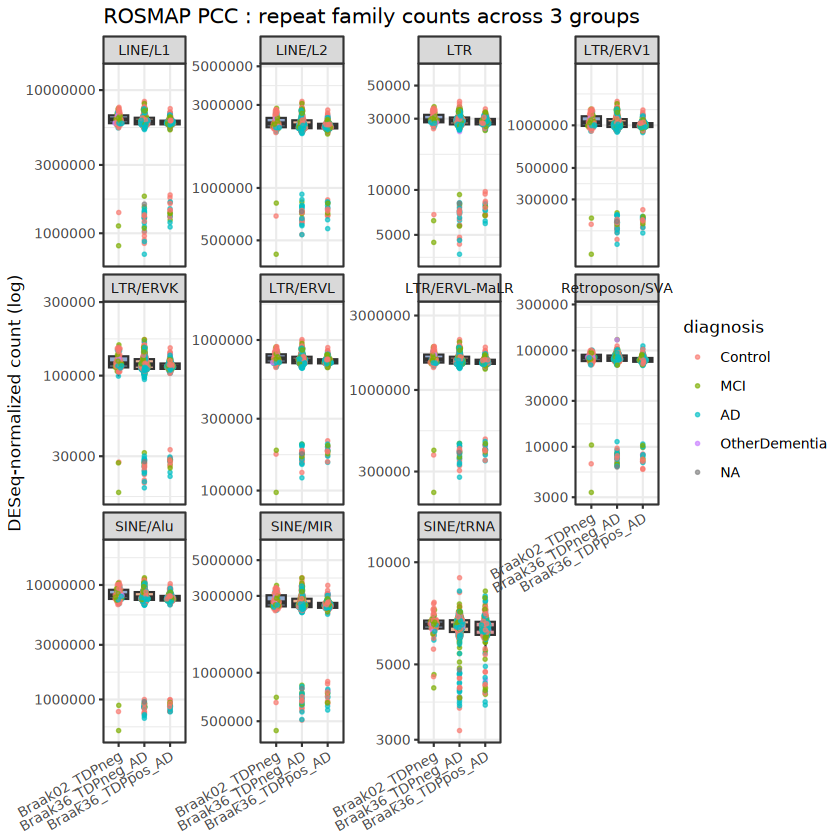

In [57]:
p_box

In [58]:
ggsave(file.path(PLOTS_DIR, "family_boxplots.pdf"),
       p_box, width = 13, height = 9, device = cairo_pdf)

In [44]:
# === 11. Per-family element-level long tibbles ================================
# WARNING: this builds large long tables. We pre-filter to expressed elements
# (>= 1 raw count in >= 5 samples) to keep memory bounded.
log_msg("Building per-family element-level long tibbles ...")
target_families <- keep_families
family_idx_list <- split(seq_len(nrow(dds)), rm_raw$class_family)
 
norm_full <- counts(dds, normalized = TRUE)
raw_full  <- counts(dds, normalized = FALSE)
 
for (fam in target_families) {
  safe <- gsub("/", "_", fam)
  idx  <- family_idx_list[[fam]]
  if (length(idx) == 0) {
    log_msg(sprintf("  %s: 0 elements - skipped", fam)); next
  }
 
  fam_norm_mat <- norm_full[idx, , drop = FALSE]
  fam_raw_mat  <- raw_full [idx, , drop = FALSE]
 
  # Filter to expressed elements to keep long tibbles tractable
  expressed <- rowSums(fam_raw_mat >= 1) >= 2
  if (!any(expressed)) {
    log_msg(sprintf("  %s: 0 expressed elements - skipped", fam)); next
  }
  fam_norm_mat  <- fam_norm_mat[expressed, , drop = FALSE]
  fam_raw_mat   <- fam_raw_mat [expressed, , drop = FALSE]
  idx_expressed <- idx[expressed]
  log_msg(sprintf("  %s: %d / %d elements expressed",
                  fam, sum(expressed), length(idx)))
 
  fam_long <-
    as_tibble(fam_norm_mat, rownames = "gene_id") %>%
    pivot_longer(-gene_id, names_to = "sample_id", values_to = "count") %>%
    left_join(
      as_tibble(fam_raw_mat, rownames = "gene_id") %>%
        pivot_longer(-gene_id, names_to = "sample_id", values_to = "raw_count"),
      by = c("gene_id", "sample_id")
    ) %>%
    left_join(
      tibble(gene_id      = rownames(fam_norm_mat),
             class_family = rm_raw$class_family[idx_expressed],
             rep_name     = rm_raw$rep_name[idx_expressed],
             chromosome   = rm_raw$chromosome[idx_expressed],
             start        = rm_raw$start[idx_expressed],
             end          = rm_raw$end[idx_expressed]),
      by = "gene_id"
    ) %>%
    left_join(
      pcc_meta %>% select(sample_id, individualID, group, diagnosis,
                          tdp43_status, braak, cerad,
                          age_death_num, sex, pmi, rin,
                          sequencingBatch, Study, cohort),
      by = "sample_id"
    )
 
  qsave(fam_long, file.path(FAMILY_DIR, sprintf("element_long_%s.qs", safe)),
        nthreads = 8, preset = "fast")
  rm(fam_norm_mat, fam_raw_mat, fam_long); gc(full = TRUE)
}
rm(norm_full, raw_full); gc(full = TRUE)

[2026-05-28 15:32:31] Building per-family element-level long tibbles ...


In [ ]:
# === 12. Per-family aggregation + emmeans (pairwise across the 3 groups) ======
log_msg("Per-family aggregation and emmeans ...")
agg_list <- list(); emm_list <- list()
 
for (fam in target_families) {
  safe  <- gsub("/", "_", fam)
  fpath <- file.path(FAMILY_DIR, sprintf("element_long_%s.qs", safe))
  if (!file.exists(fpath)) next
 
  fam_long <- qread(fpath)
 
  fam_agg <- fam_long %>%
    group_by(sample_id, class_family) %>%
    summarise(count     = sum(count),
              raw_count = sum(raw_count),
              .groups   = "drop") %>%
    left_join(
      pcc_meta %>% select(sample_id, individualID, group, diagnosis,
                          tdp43_status, braak,
                          age_death_num, sex, pmi, rin,
                          sequencingBatch, Study, cohort),
      by = "sample_id"
    )
  agg_list[[fam]] <- fam_agg
 
  fit <- lm(
    log2(count + 1) ~ group + sex + age_death_num +
                       rin + sequencingBatch + Study,
    data = fam_agg
  )
  emm <- emmeans::emmeans(fit, pairwise ~ group, adjust = "none") %>%
    pluck("contrasts") %>%
    as_tibble() %>%
    mutate(class_family = fam)
  emm_list[[fam]] <- emm
 
  rm(fam_long, fam_agg, fit, emm); gc(full = TRUE)
}
 
repeat_norm_counts_family_agg <- bind_rows(agg_list) %>%
  mutate(class_family = factor(class_family, levels = target_families))
 
family_emm_res <- bind_rows(emm_list) %>%
  group_by(contrast) %>%
  mutate(padj = p.adjust(p.value, method = "BH")) %>%
  ungroup() %>%
  mutate(class_family = factor(class_family, levels = target_families)) %>%
  arrange(contrast, class_family)
 
write_csv(repeat_norm_counts_family_agg,
          file.path(OUT_DIR, "repeat_norm_counts_family_agg.csv"))
qsave(repeat_norm_counts_family_agg,
      file.path(OUT_DIR, "repeat_norm_counts_family_agg.qs"),
      nthreads = 8, preset = "fast")
write_csv(family_emm_res, file.path(OUT_DIR, "family_emm_res.csv"))
qsave(family_emm_res, file.path(OUT_DIR, "family_emm_res.qs"),
      nthreads = 8, preset = "fast")
 
log_msg("family_emm_res:")
print(family_emm_res, n = Inf)

In [ ]:
# === 14. Plots ================================================================
options(ggplot2.device = cairo_pdf)
log_msg("Generating plots ...")
group_colors <- c(Braak02_TDPneg     = "#4C72B0",
                  Braak36_TDPneg_AD  = "#DD8452",
                  Braak36_TDPpos_AD  = "#C44E52")
 
# (a) Forest per contrast — emmeans effect ± CI
family_emm_plot <- family_emm_res %>%
  mutate(
    ci_low  = estimate - qnorm(0.975) * SE,
    ci_high = estimate + qnorm(0.975) * SE,
    sig     = padj < 0.05
  )
 
p_forest <- family_emm_plot %>%
  ggplot(aes(estimate, class_family, color = sig)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_pointrange(aes(xmin = ci_low, xmax = ci_high), size = .4) +
  geom_text(aes(label = signif(padj, 2)),
            hjust = -0.2, size = 2.6, color = "black") +
  scale_color_manual(values = c(`TRUE` = "firebrick", `FALSE` = "grey40"),
                     guide = "none") +
  facet_wrap(~ contrast, ncol = 1, scales = "free_x") +
  theme_bw(base_size = 10) +
  labs(x = "log2(count+1) effect +/- 95% CI",
       y = NULL,
       title = "ROSMAP PCC : repeat family expression across 3 groups",
       subtitle = "emmeans pairwise on family-aggregated counts")
 
ggsave(file.path(PLOTS_DIR, "family_emm_forest.pdf"),
       p_forest, width = 8, height = 10, device = cairo_pdf)
 
# (b) Bar plot per contrast
p_bars <- family_emm_plot %>%
  ggplot(aes(estimate, class_family, fill = sig)) +
  geom_col() +
  geom_text(aes(label = signif(padj, 2)),
            hjust = -0.1, size = 2.6) +
  scale_fill_manual(values = c(`TRUE` = "#c62a2a", `FALSE` = "#6d6868"),
                    guide = "none") +
  facet_wrap(~ contrast, ncol = 1, scales = "free_x") +
  theme_bw(base_size = 10) +
  labs(x = "Effect on log2(count+1)", y = NULL,
       title = "Per-family effect across 3-group contrasts")
 
ggsave(file.path(PLOTS_DIR, "family_emm_bars.pdf"),
       p_bars, width = 8, height = 10, device = cairo_pdf)
 
# (c) Per-family boxplots, faceted by family, colored by group
make_family_box <- function(agg_tbl, padj_tbl, title) {
  agg_tbl %>%
    ggplot(aes(group, count, fill = group)) +
    geom_boxplot(outlier.shape = NA, alpha = .6) +
    geom_quasirandom(aes(color = diagnosis),
                     width = .15, size = .6, alpha = .65) +
    scale_fill_manual(values = group_colors, guide = "none") +
    ggnewscale::new_scale_color() +
    scale_y_log10(expand = expansion(mult = c(.08, .25))) +
    ggh4x::facet_wrap2(~ class_family, scales = "free_y",
                       axes = "y", ncol = 4) +
    theme_bw(base_size = 10) +
    theme(axis.text.x = element_text(angle = 30, hjust = 1)) +
    labs(x = NULL, y = "DESeq-normalized count (log)", title = title) +
    coord_cartesian(clip = "off")
}
 
p_box <- make_family_box(
  repeat_norm_counts_family_agg, NULL,
  "ROSMAP PCC -- repeat family counts across 3 groups"
)
ggsave(file.path(PLOTS_DIR, "family_boxplots.pdf"),
       p_box, width = 13, height = 9, device = cairo_pdf)
 

In [39]:
# === 8. Free upstream objects =================================================
rm(meta_raw, rosmap_repeat_counts, repeat_counts_mat, repeat_counts_int)
gc(full = TRUE)
 
oso <- sapply(ls(), function(x) object.size(get(x, envir = .GlobalEnv)))
log_msg("Top in-memory objects:")
print(sort(oso, decreasing = TRUE)[1:10] |> format(units = "GB", standard = "SI"))
 
qsave(dds, file.path(OUT_DIR, "dds_pre_deseq.qs"),
      nthreads = 4, preset = "fast")
log_msg("Saved pre-DESeq dds checkpoint")

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,15158529,809.6,33612367,1795.1,24475750,1307.2
Vcells,617120118,4708.3,8012178120,61128.1,8280852234,63177.9


[2026-05-21 23:24:03] Top in-memory objects:
                dds              rm_raw         gene_counts gene_counts_aligned 
       "4409243784"        " 759631912"        " 177794536"        "  81791376" 
          keep_rows            pcc_meta                  mm     clean_sample_id 
       "  15846296"        "    160632"        "     47304"        "     30584" 
         de_coldata    unmatched_counts 
       "     28832"        "     21896" 
[2026-05-21 23:24:08] Saved pre-DESeq dds checkpoint


In [ ]:
# === 9. Run DESeq (NO row pre-filter) =========================================
log_msg(sprintf("Starting DESeq() on %d features x %d samples ...",
                nrow(dds), ncol(dds)))
t_d <- Sys.time()
dds <- DESeq(dds,
             parallel             = FALSE,
             #BPPARAM              = MulticoreParam(workers = 8),
             minReplicatesForReplace = Inf)
log_msg(sprintf("DESeq() complete in %.2f hours",
                as.numeric(difftime(Sys.time(), t_d, units = "hours"))))
 
qsave(dds, file.path(OUT_DIR, "rosmap_pcc_repeat_de_3groups.qs"),
      nthreads = 8, preset = "fast")
log_msg("Saved fitted dds")
print(resultsNames(dds))

[2026-05-21 23:24:47] Starting DESeq() on 3961562 features x 241 samples ...


Warning message in ns(age_death_num, df = 3):
“shoving 'interior' knots matching boundary knots to inside”
using pre-existing size factors

estimating dispersions

Warning message in ns(age_death_num, df = 3):
“shoving 'interior' knots matching boundary knots to inside”
gene-wise dispersion estimates

Warning message in ns(age_death_num, df = 3):
“shoving 'interior' knots matching boundary knots to inside”


In [44]:
1

[1] 1

In [42]:
2

[1] 2

In [43]:
print(resultsNames(dds))

 [1] "Intercept"                                
 [2] "sex_M_vs_F"                               
 [3] "ns.age_death_num..df...3.1"               
 [4] "ns.age_death_num..df...3.2"               
 [5] "ns.age_death_num..df...3.3"               
 [6] "rin"                                      
 [7] "sequencingBatch_NYGC2_vs_NYGC1"           
 [8] "sequencingBatch_NYGC3_vs_NYGC1"           
 [9] "sequencingBatch_RISK_2_vs_NYGC1"          
[10] "sequencingBatch_RISK_3_vs_NYGC1"          
[11] "sequencingBatch_RISK_4_vs_NYGC1"          
[12] "Study_ROS_vs_MAP"                         
[13] "group_Braak36_TDPneg_AD_vs_Braak02_TDPneg"
[14] "group_Braak36_TDPpos_AD_vs_Braak02_TDPneg"


In [45]:
dim(dds)

[1] 3961562     241

In [46]:
# === 10. Extract three contrasts with ashr shrinkage ==========================
extract_deseq_result <- function(de, contrast = NULL, name = NULL) {
  if (!is.null(name)) {
    res      <- results(de, name = name)
    shrunken <- lfcShrink(de, coef = name, res = res, type = "ashr")
  } else {
    res      <- results(de, contrast = contrast)
    shrunken <- lfcShrink(de, contrast = contrast, res = res, type = "ashr")
  }
  shrunken %>%
    as_tibble(rownames = "gene_id") %>%
    left_join(
      res %>% as_tibble(rownames = "gene_id") %>%
        select(gene_id, log2FoldChange, lfcSE),
      by = "gene_id", suffix = c("", "_MLE")
    )
}
 
attach_family <- function(res_tbl, dds_obj = dds) {
  if ("class_family" %in% colnames(res_tbl)) return(res_tbl)
  res_tbl %>%
    mutate(row_idx      = match(gene_id, rownames(dds_obj)),
           class_family = rm_raw$class_family[row_idx],
           rep_name     = rm_raw$rep_name[row_idx]) %>%
    select(-row_idx)
}
 
# Define the three contrasts. Reference level is Braak02_TDPneg.
contrast_specs <- list(
  AD_vs_lowBraak       = c("group", "Braak36_TDPneg_AD", "Braak02_TDPneg"),
  ADtdp_vs_lowBraak    = c("group", "Braak36_TDPpos_AD", "Braak02_TDPneg"),
  tdp_within_AD        = c("group", "Braak36_TDPpos_AD", "Braak36_TDPneg_AD")
)
 
res_list <- list()
for (nm in names(contrast_specs)) {
  log_msg(sprintf("Extracting contrast: %s", nm))
  res_list[[nm]] <- extract_deseq_result(dds, contrast = contrast_specs[[nm]]) %>%
    attach_family() %>%
    mutate(contrast = nm)
  qsave(res_list[[nm]],
        file.path(OUT_DIR, sprintf("res_%s.qs", nm)),
        nthreads = 8, preset = "fast")
  write_csv(res_list[[nm]],
            file.path(OUT_DIR, sprintf("res_%s.csv", nm)))
  log_msg(sprintf("  %s: %d rows saved", nm, nrow(res_list[[nm]])))
}
 
# Combine results with global BH correction across all three contrasts
res_all <- bind_rows(res_list) %>%
  mutate(padj_global = p.adjust(pvalue, method = "BH"))
write_csv(res_all, file.path(OUT_DIR, "res_all_3contrasts.csv"))
qsave(res_all, file.path(OUT_DIR, "res_all_3contrasts.qs"),
      nthreads = 8, preset = "fast")
log_msg(sprintf("Saved combined res_all (%d rows = %d features x 3 contrasts)",
                nrow(res_all), nrow(res_list[[1]])))

[2026-05-22 12:13:32] Extracting contrast: AD_vs_lowBraak


using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



[2026-05-22 12:18:16]   AD_vs_lowBraak: 3961562 rows saved
[2026-05-22 12:18:16] Extracting contrast: ADtdp_vs_lowBraak


using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



[2026-05-22 12:22:57]   ADtdp_vs_lowBraak: 3961562 rows saved
[2026-05-22 12:22:57] Extracting contrast: tdp_within_AD


using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



[2026-05-22 12:38:13]   tdp_within_AD: 3961562 rows saved
[2026-05-22 12:38:23] Saved combined res_all (11884686 rows = 3961562 features x 3 contrasts)


In [47]:
1

[1] 1

In [48]:
# === 11. Per-family element-level long tibbles ================================
# WARNING: this builds large long tables. We pre-filter to expressed elements
# (>= 1 raw count in >= 5 samples) to keep memory bounded.
log_msg("Building per-family element-level long tibbles ...")
target_families <- keep_families
family_idx_list <- split(seq_len(nrow(dds)), rm_raw$class_family)
 
norm_full <- counts(dds, normalized = TRUE)
raw_full  <- counts(dds, normalized = FALSE)
 
for (fam in target_families) {
  safe <- gsub("/", "_", fam)
  idx  <- family_idx_list[[fam]]
  if (length(idx) == 0) {
    log_msg(sprintf("  %s: 0 elements - skipped", fam)); next
  }
 
  fam_norm_mat <- norm_full[idx, , drop = FALSE]
  fam_raw_mat  <- raw_full [idx, , drop = FALSE]
 
  # Filter to expressed elements to keep long tibbles tractable
  expressed <- rowSums(fam_raw_mat >= 1) >= 5
  if (!any(expressed)) {
    log_msg(sprintf("  %s: 0 expressed elements - skipped", fam)); next
  }
  fam_norm_mat  <- fam_norm_mat[expressed, , drop = FALSE]
  fam_raw_mat   <- fam_raw_mat [expressed, , drop = FALSE]
  idx_expressed <- idx[expressed]
  log_msg(sprintf("  %s: %d / %d elements expressed",
                  fam, sum(expressed), length(idx)))
 
  fam_long <-
    as_tibble(fam_norm_mat, rownames = "gene_id") %>%
    pivot_longer(-gene_id, names_to = "sample_id", values_to = "count") %>%
    left_join(
      as_tibble(fam_raw_mat, rownames = "gene_id") %>%
        pivot_longer(-gene_id, names_to = "sample_id", values_to = "raw_count"),
      by = c("gene_id", "sample_id")
    ) %>%
    left_join(
      tibble(gene_id      = rownames(fam_norm_mat),
             class_family = rm_raw$class_family[idx_expressed],
             rep_name     = rm_raw$rep_name[idx_expressed],
             chromosome   = rm_raw$chromosome[idx_expressed],
             start        = rm_raw$start[idx_expressed],
             end          = rm_raw$end[idx_expressed]),
      by = "gene_id"
    ) %>%
    left_join(
      pcc_meta %>% select(sample_id, individualID, group, diagnosis,
                          tdp43_status, braak, cerad,
                          age_death_num, sex, pmi, rin,
                          sequencingBatch, Study, cohort),
      by = "sample_id"
    )
 
  qsave(fam_long, file.path(FAMILY_DIR, sprintf("element_long_%s.qs", safe)),
        nthreads = 8, preset = "fast")
  rm(fam_norm_mat, fam_raw_mat, fam_long); gc(full = TRUE)
}
rm(norm_full, raw_full); gc(full = TRUE)

[2026-05-22 12:43:39] Building per-family element-level long tibbles ...
[2026-05-22 12:44:08]   SINE/Alu: 985188 / 1180757 elements expressed
[2026-05-22 12:47:42]   SINE/MIR: 494558 / 594089 elements expressed
[2026-05-22 12:49:24]   SINE/tRNA: 1884 / 2245 elements expressed
[2026-05-22 12:49:30]   LINE/L1: 763679 / 951537 elements expressed
[2026-05-22 12:52:10]   LINE/L2: 432818 / 519582 elements expressed
[2026-05-22 12:53:40]   LTR: 6498 / 8203 elements expressed
[2026-05-22 12:53:44]   LTR/ERV1: 135118 / 176030 elements expressed
[2026-05-22 12:54:10]   LTR/ERVK: 8575 / 10633 elements expressed
[2026-05-22 12:54:14]   LTR/ERVL: 123684 / 162449 elements expressed
[2026-05-22 12:54:41]   LTR/ERVL-MaLR: 273095 / 350672 elements expressed
[2026-05-22 12:55:37]   Retroposon/SVA: 4575 / 5365 elements expressed


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,16425181,877.2,33612393,1795.1,33612393,1795.1
Vcells,4062110570,30991.5,12955213842,98840.5,14056202677,107240.4


In [49]:
1

[1] 1

In [50]:
# === 12. Per-family aggregation + emmeans (pairwise across the 3 groups) ======
log_msg("Per-family aggregation and emmeans ...")
agg_list <- list(); emm_list <- list()
 
for (fam in target_families) {
  safe  <- gsub("/", "_", fam)
  fpath <- file.path(FAMILY_DIR, sprintf("element_long_%s.qs", safe))
  if (!file.exists(fpath)) next
 
  fam_long <- qread(fpath)
 
  fam_agg <- fam_long %>%
    group_by(sample_id, class_family) %>%
    summarise(count     = sum(count),
              raw_count = sum(raw_count),
              .groups   = "drop") %>%
    left_join(
      pcc_meta %>% select(sample_id, individualID, group, diagnosis,
                          tdp43_status, braak,
                          age_death_num, sex, pmi, rin,
                          sequencingBatch, Study, cohort),
      by = "sample_id"
    )
  agg_list[[fam]] <- fam_agg
 
  fit <- lm(
    log2(count + 1) ~ group + sex + ns(age_death_num, df = 3) +
                       rin + sequencingBatch + Study,
    data = fam_agg
  )
  emm <- emmeans::emmeans(fit, pairwise ~ group, adjust = "none") %>%
    pluck("contrasts") %>%
    as_tibble() %>%
    mutate(class_family = fam)
  emm_list[[fam]] <- emm
 
  rm(fam_long, fam_agg, fit, emm); gc(full = TRUE)
}
 
repeat_norm_counts_family_agg <- bind_rows(agg_list) %>%
  mutate(class_family = factor(class_family, levels = target_families))
 
family_emm_res <- bind_rows(emm_list) %>%
  group_by(contrast) %>%
  mutate(padj = p.adjust(p.value, method = "BH")) %>%
  ungroup() %>%
  mutate(class_family = factor(class_family, levels = target_families)) %>%
  arrange(contrast, class_family)
 
write_csv(repeat_norm_counts_family_agg,
          file.path(OUT_DIR, "repeat_norm_counts_family_agg.csv"))
qsave(repeat_norm_counts_family_agg,
      file.path(OUT_DIR, "repeat_norm_counts_family_agg.qs"),
      nthreads = 8, preset = "fast")
write_csv(family_emm_res, file.path(OUT_DIR, "family_emm_res.csv"))
qsave(family_emm_res, file.path(OUT_DIR, "family_emm_res.qs"),
      nthreads = 8, preset = "fast")
 
log_msg("family_emm_res:")
print(family_emm_res, n = Inf)

[2026-05-22 12:56:40] Per-family aggregation and emmeans ...


Warning message in ns(age_death_num, df = 3):
“shoving 'interior' knots matching boundary knots to inside”
Warning message in ns(age_death_num, df = 3):
“shoving 'interior' knots matching boundary knots to inside”
Warning message in ns(age_death_num, df = 3):
“shoving 'interior' knots matching boundary knots to inside”
Warning message in ns(age_death_num, df = 3):
“shoving 'interior' knots matching boundary knots to inside”
Warning message in ns(age_death_num, df = 3):
“shoving 'interior' knots matching boundary knots to inside”
Warning message in ns(age_death_num, df = 3):
“shoving 'interior' knots matching boundary knots to inside”


[2026-05-22 13:01:46] family_emm_res:
# A tibble: 33 × 8
   contrast            estimate     SE    df t.ratio p.value class_family   padj
   <chr>                  <dbl>  <dbl> <dbl>   <dbl>   <dbl> <fct>         <dbl>
 1 Braak02_TDPneg - B…  1.90e-2 0.0219   227  0.869  0.386   SINE/Alu     0.489 
 2 Braak02_TDPneg - B…  1.53e-2 0.0200   227  0.767  0.444   SINE/MIR     0.489 
 3 Braak02_TDPneg - B…  1.60e-2 0.0147   227  1.09   0.278   SINE/tRNA    0.489 
 4 Braak02_TDPneg - B…  2.51e-2 0.0203   227  1.24   0.218   LINE/L1      0.489 
 5 Braak02_TDPneg - B…  1.61e-2 0.0202   227  0.800  0.424   LINE/L2      0.489 
 6 Braak02_TDPneg - B…  1.92e-2 0.0211   227  0.906  0.366   LTR          0.489 
 7 Braak02_TDPneg - B…  2.23e-2 0.0205   227  1.09   0.278   LTR/ERV1     0.489 
 8 Braak02_TDPneg - B…  2.66e-2 0.0211   227  1.26   0.208   LTR/ERVK     0.489 
 9 Braak02_TDPneg - B…  1.66e-2 0.0196   227  0.845  0.399   LTR/ERVL     0.489 
10 Braak02_TDPneg - B…  1.52e-2 0.0194   227  0.784 

In [51]:
# === 13. Per-family element-level summaries (DE counts per contrast) ==========
log_msg("Per-family element-level summaries ...")
 
family_stats <- function(res_tbl) {
  res_tbl <- attach_family(res_tbl)
  res_tbl %>%
    filter(class_family %in% target_families) %>%
    group_by(class_family) %>%
    summarize(
      n              = n(),
      n_de           = sum(padj < .05, na.rm = TRUE),
      n_down         = sum(log2FoldChange < 0 & padj < .05, na.rm = TRUE),
      n_up           = sum(log2FoldChange > 0 & padj < .05, na.rm = TRUE),
      prop_de        = n_de / n,
      prop_down      = n_down / n,
      prop_up        = n_up / n,
      pct_up_total   = mean(log2FoldChange > 0, na.rm = TRUE) * 100,
      pct_down_total = mean(log2FoldChange < 0, na.rm = TRUE) * 100,
      mean_lfc       = mean(log2FoldChange, na.rm = TRUE),
      median_lfc     = median(log2FoldChange, na.rm = TRUE),
      .groups        = "drop"
    ) %>%
    mutate(class_family = factor(class_family, levels = target_families)) %>%
    arrange(class_family)
}
 
stats_list <- list()
for (nm in names(res_list)) {
  s <- family_stats(res_list[[nm]]) %>% mutate(contrast = nm)
  stats_list[[nm]] <- s
  write_csv(s, file.path(OUT_DIR, sprintf("family_stats_%s.csv", nm)))
}
stats_all <- bind_rows(stats_list)
write_csv(stats_all, file.path(OUT_DIR, "family_stats_all.csv"))

[2026-05-22 13:01:47] Per-family element-level summaries ...


In [52]:
# === 14. Plots ================================================================
options(ggplot2.device = cairo_pdf)
log_msg("Generating plots ...")
group_colors <- c(Braak02_TDPneg     = "#4C72B0",
                  Braak36_TDPneg_AD  = "#DD8452",
                  Braak36_TDPpos_AD  = "#C44E52")
 
# (a) Forest per contrast — emmeans effect ± CI
family_emm_plot <- family_emm_res %>%
  mutate(
    ci_low  = estimate - qnorm(0.975) * SE,
    ci_high = estimate + qnorm(0.975) * SE,
    sig     = padj < 0.05
  )
 
p_forest <- family_emm_plot %>%
  ggplot(aes(estimate, class_family, color = sig)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_pointrange(aes(xmin = ci_low, xmax = ci_high), size = .4) +
  geom_text(aes(label = signif(padj, 2)),
            hjust = -0.2, size = 2.6, color = "black") +
  scale_color_manual(values = c(`TRUE` = "firebrick", `FALSE` = "grey40"),
                     guide = "none") +
  facet_wrap(~ contrast, ncol = 1, scales = "free_x") +
  theme_bw(base_size = 10) +
  labs(x = "log2(count+1) effect +/- 95% CI",
       y = NULL,
       title = "ROSMAP PCC : repeat family expression across 3 groups",
       subtitle = "emmeans pairwise on family-aggregated counts")
 
ggsave(file.path(PLOTS_DIR, "family_emm_forest.pdf"),
       p_forest, width = 8, height = 10, device = cairo_pdf)
 
# (b) Bar plot per contrast
p_bars <- family_emm_plot %>%
  ggplot(aes(estimate, class_family, fill = sig)) +
  geom_col() +
  geom_text(aes(label = signif(padj, 2)),
            hjust = -0.1, size = 2.6) +
  scale_fill_manual(values = c(`TRUE` = "#c62a2a", `FALSE` = "#6d6868"),
                    guide = "none") +
  facet_wrap(~ contrast, ncol = 1, scales = "free_x") +
  theme_bw(base_size = 10) +
  labs(x = "Effect on log2(count+1)", y = NULL,
       title = "Per-family effect across 3-group contrasts")
 
ggsave(file.path(PLOTS_DIR, "family_emm_bars.pdf"),
       p_bars, width = 8, height = 10, device = cairo_pdf)
 
# (c) Per-family boxplots, faceted by family, colored by group
make_family_box <- function(agg_tbl, padj_tbl, title) {
  agg_tbl %>%
    ggplot(aes(group, count, fill = group)) +
    geom_boxplot(outlier.shape = NA, alpha = .6) +
    geom_quasirandom(aes(color = diagnosis),
                     width = .15, size = .6, alpha = .65) +
    scale_fill_manual(values = group_colors, guide = "none") +
    ggnewscale::new_scale_color() +
    scale_y_log10(expand = expansion(mult = c(.08, .25))) +
    ggh4x::facet_wrap2(~ class_family, scales = "free_y",
                       axes = "y", ncol = 4) +
    theme_bw(base_size = 10) +
    theme(axis.text.x = element_text(angle = 30, hjust = 1)) +
    labs(x = NULL, y = "DESeq-normalized count (log)", title = title) +
    coord_cartesian(clip = "off")
}
 
p_box <- make_family_box(
  repeat_norm_counts_family_agg, NULL,
  "ROSMAP PCC -- repeat family counts across 3 groups"
)
ggsave(file.path(PLOTS_DIR, "family_boxplots.pdf"),
       p_box, width = 13, height = 9, device = cairo_pdf)
 
# (d) Per-family volcanoes per contrast
make_family_volcano <- function(res, fam, title) {
  d <- res %>%
    filter(class_family == fam,
           !is.na(pvalue),
           is.finite(log2FoldChange)) %>%
    arrange(desc(pvalue))
  d %>%
    ggplot(aes(log2FoldChange, -log10(pvalue), color = padj < 0.05)) +
    rasterize(geom_point(shape = 16, alpha = .5), dpi = 200, dev = "ragg") +
    scale_color_manual(values = c(`TRUE` = "red", `FALSE` = "grey40"),
                       na.value = "grey80") +
    scale_x_continuous(limits = c(-6, 6), oob = scales::squish) +
    theme_bw(base_size = 10) +
    labs(title = sprintf("%s -- %s", fam, title),
         x = "log2 fold-change (shrunken)", y = "-log10(p)")
}
 
for (nm in names(res_list)) {
  this_dir <- file.path(VOLCANO_DIR, nm)
  dir.create(this_dir, showWarnings = FALSE, recursive = TRUE)
  for (fam in target_families) {
    safe <- gsub("/", "_", fam)
    ggsave(file.path(this_dir,
                     sprintf("volcano_%s_%s.pdf", safe, nm)),
           make_family_volcano(res_list[[nm]], fam, nm),
           width = 6, height = 5, device = cairo_pdf)
  }
}
 
# (e) Directional consistency per contrast
direction_tbl <- res_all %>%
  filter(class_family %in% target_families,
         is.finite(log2FoldChange)) %>%
  group_by(contrast, class_family) %>%
  summarise(n_elements = n(),
            pct_up     = mean(log2FoldChange > 0) * 100,
            pct_down   = mean(log2FoldChange < 0) * 100,
            .groups    = "drop") %>%
  mutate(class_family = factor(class_family, levels = target_families))
 
p_direction <- direction_tbl %>%
  pivot_longer(c(pct_up, pct_down),
               names_to = "direction", values_to = "pct") %>%
  ggplot(aes(pct, class_family, fill = direction)) +
  geom_col(position = "stack") +
  geom_vline(xintercept = 50, linetype = "dashed", color = "grey40") +
  scale_fill_manual(values = c(pct_up = "#c66565", pct_down = "#5680c6")) +
  facet_wrap(~ contrast, ncol = 1) +
  theme_bw(base_size = 10) +
  labs(x = "% elements with positive / negative LFC", y = NULL,
       title = "Per-family directional consistency across contrasts")
 
ggsave(file.path(PLOTS_DIR, "element_directional_consistency.pdf"),
       p_direction, width = 8, height = 9, device = cairo_pdf)
 
# (f) DE element counts per family per contrast
p_de_counts <- stats_all %>%
  select(contrast, class_family, n_up, n_down) %>%
  pivot_longer(c(n_up, n_down),
               names_to = "direction", values_to = "n_de") %>%
  ggplot(aes(n_de, class_family, fill = direction)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  scale_fill_manual(values = c(n_up = "#c62a2a", n_down = "#2b6cb0")) +
  facet_wrap(~ contrast, ncol = 1, scales = "free_x") +
  theme_bw(base_size = 10) +
  labs(x = "# DE elements (padj < 0.05)", y = NULL,
       title = "DE element counts per family across contrasts")
 
ggsave(file.path(PLOTS_DIR, "family_de_counts.pdf"),
       p_de_counts, width = 8, height = 9, device = cairo_pdf)
 
# (g) PCA QC
log_msg("PCA QC ...")
vst_dds <- vst(dds, blind = FALSE)
pca_data <- plotPCA(vst_dds, intgroup = "group",
                    returnData = TRUE, ntop = 5000) %>%
  rownames_to_column("sample_id_pca") %>%
  left_join(pcc_meta %>%
              select(sample_id, sex, diagnosis, sequencingBatch,
                     age_death_num, Study, cohort, group, tdp43_status, braak),
            by = c("name" = "sample_id"))
 
make_pca <- function(color_var, title) {
  ggplot(pca_data, aes(PC1, PC2, color = .data[[color_var]])) +
    geom_point(size = 2, alpha = 0.8) +
    theme_bw(base_size = 10) +
    labs(title = paste("PCA --", title))
}
 
library(patchwork)
p_pca <- (make_pca("group",           "Group")          |
          make_pca("diagnosis",       "Diagnosis"))    /
         (make_pca("tdp43_status",    "TDP-43 status") |
          make_pca("sex",             "Sex"))          /
         (make_pca("sequencingBatch", "Batch")         |
          make_pca("cohort",          "Cohort"))       /
         (make_pca("Study",           "Study (ROS/MAP)") |
          ggplot(pca_data, aes(PC1, age_death_num, color = group)) +
            geom_point(alpha = 0.8) + geom_smooth(method = "lm", se = FALSE) +
            scale_color_manual(values = group_colors) +
            theme_bw(base_size = 10) +
            labs(title = "PC1 vs age at death"))
 
ggsave(file.path(PLOTS_DIR, "pca_qc.pdf"),
       p_pca, width = 14, height = 15, device = cairo_pdf)

[2026-05-22 13:01:48] Generating plots ...


using ntop=5000 top features by variance



ERROR: [1m[33mError[39m in `geom_point()`:[22m
[1m[22m[33m![39m Problem while computing aesthetics.
[36mℹ[39m Error occurred in the 1st layer.
[1mCaused by error in `.data[["group"]]`:[22m
[1m[22m[33m![39m Column `group` not found in `.data`.


In [ ]:
# === 15. Done =================================================================
t_end <- Sys.time()
log_msg(sprintf("=== Pipeline finished in %.2f hours ===",
                as.numeric(difftime(t_end, t_start, units = "hours"))))
log_msg(sprintf("All outputs in %s/", OUT_DIR))
sessionInfo()

In [ ]:
# === 14. Plots ================================================================
options(ggplot2.device = cairo_pdf)
log_msg("Generating plots ...")
group_colors <- c(Braak02_TDPneg     = "#4C72B0",
                  Braak36_TDPneg_AD  = "#DD8452",
                  Braak36_TDPpos_AD  = "#C44E52")
 
# (a) Forest per contrast — emmeans effect ± CI
family_emm_plot <- family_emm_res %>%
  mutate(
    ci_low  = estimate - qnorm(0.975) * SE,
    ci_high = estimate + qnorm(0.975) * SE,
    sig     = padj < 0.05
  )
 
p_forest <- family_emm_plot %>%
  ggplot(aes(estimate, class_family, color = sig)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  geom_pointrange(aes(xmin = ci_low, xmax = ci_high), size = .4) +
  geom_text(aes(label = signif(padj, 2)),
            hjust = -0.2, size = 2.6, color = "black") +
  scale_color_manual(values = c(`TRUE` = "firebrick", `FALSE` = "grey40"),
                     guide = "none") +
  facet_wrap(~ contrast, ncol = 1, scales = "free_x") +
  theme_bw(base_size = 10) +
  labs(x = "log2(count+1) effect +/- 95% CI",
       y = NULL,
       title = "ROSMAP PCC : repeat family expression across 3 groups",
       subtitle = "emmeans pairwise on family-aggregated counts")
 
ggsave(file.path(PLOTS_DIR, "family_emm_forest.pdf"),
       p_forest, width = 8, height = 10, device = cairo_pdf)
 
# (b) Bar plot per contrast
p_bars <- family_emm_plot %>%
  ggplot(aes(estimate, class_family, fill = sig)) +
  geom_col() +
  geom_text(aes(label = signif(padj, 2)),
            hjust = -0.1, size = 2.6) +
  scale_fill_manual(values = c(`TRUE` = "#c62a2a", `FALSE` = "#6d6868"),
                    guide = "none") +
  facet_wrap(~ contrast, ncol = 1, scales = "free_x") +
  theme_bw(base_size = 10) +
  labs(x = "Effect on log2(count+1)", y = NULL,
       title = "Per-family effect across 3-group contrasts")
 
ggsave(file.path(PLOTS_DIR, "family_emm_bars.pdf"),
       p_bars, width = 8, height = 10, device = cairo_pdf)
 
# (c) Per-family boxplots, faceted by family, colored by group
make_family_box <- function(agg_tbl, padj_tbl, title) {
  agg_tbl %>%
    ggplot(aes(group, count, fill = group)) +
    geom_boxplot(outlier.shape = NA, alpha = .6) +
    geom_quasirandom(aes(color = diagnosis),
                     width = .15, size = .6, alpha = .65) +
    scale_fill_manual(values = group_colors, guide = "none") +
    ggnewscale::new_scale_color() +
    scale_y_log10(expand = expansion(mult = c(.08, .25))) +
    ggh4x::facet_wrap2(~ class_family, scales = "free_y",
                       axes = "y", ncol = 4) +
    theme_bw(base_size = 10) +
    theme(axis.text.x = element_text(angle = 30, hjust = 1)) +
    labs(x = NULL, y = "DESeq-normalized count (log)", title = title) +
    coord_cartesian(clip = "off")
}
 
p_box <- make_family_box(
  repeat_norm_counts_family_agg, NULL,
  "ROSMAP PCC -- repeat family counts across 3 groups"
)
ggsave(file.path(PLOTS_DIR, "family_boxplots.pdf"),
       p_box, width = 13, height = 9, device = cairo_pdf)
 
# (d) Per-family volcanoes per contrast
make_family_volcano <- function(res, fam, title) {
  d <- res %>%
    filter(class_family == fam,
           !is.na(pvalue),
           is.finite(log2FoldChange)) %>%
    arrange(desc(pvalue))
  d %>%
    ggplot(aes(log2FoldChange, -log10(pvalue), color = padj < 0.05)) +
    rasterize(geom_point(shape = 16, alpha = .5), dpi = 200, dev = "ragg") +
    scale_color_manual(values = c(`TRUE` = "red", `FALSE` = "grey40"),
                       na.value = "grey80") +
    scale_x_continuous(limits = c(-6, 6), oob = scales::squish) +
    theme_bw(base_size = 10) +
    labs(title = sprintf("%s -- %s", fam, title),
         x = "log2 fold-change (shrunken)", y = "-log10(p)")
}
 
for (nm in names(res_list)) {
  this_dir <- file.path(VOLCANO_DIR, nm)
  dir.create(this_dir, showWarnings = FALSE, recursive = TRUE)
  for (fam in target_families) {
    safe <- gsub("/", "_", fam)
    ggsave(file.path(this_dir,
                     sprintf("volcano_%s_%s.pdf", safe, nm)),
           make_family_volcano(res_list[[nm]], fam, nm),
           width = 6, height = 5, device = cairo_pdf)
  }
}
 
# (e) Directional consistency per contrast
direction_tbl <- res_all %>%
  filter(class_family %in% target_families,
         is.finite(log2FoldChange)) %>%
  group_by(contrast, class_family) %>%
  summarise(n_elements = n(),
            pct_up     = mean(log2FoldChange > 0) * 100,
            pct_down   = mean(log2FoldChange < 0) * 100,
            .groups    = "drop") %>%
  mutate(class_family = factor(class_family, levels = target_families))
 
p_direction <- direction_tbl %>%
  pivot_longer(c(pct_up, pct_down),
               names_to = "direction", values_to = "pct") %>%
  ggplot(aes(pct, class_family, fill = direction)) +
  geom_col(position = "stack") +
  geom_vline(xintercept = 50, linetype = "dashed", color = "grey40") +
  scale_fill_manual(values = c(pct_up = "#c66565", pct_down = "#5680c6")) +
  facet_wrap(~ contrast, ncol = 1) +
  theme_bw(base_size = 10) +
  labs(x = "% elements with positive / negative LFC", y = NULL,
       title = "Per-family directional consistency across contrasts")
 
ggsave(file.path(PLOTS_DIR, "element_directional_consistency.pdf"),
       p_direction, width = 8, height = 9, device = cairo_pdf)
 
# (f) DE element counts per family per contrast
p_de_counts <- stats_all %>%
  select(contrast, class_family, n_up, n_down) %>%
  pivot_longer(c(n_up, n_down),
               names_to = "direction", values_to = "n_de") %>%
  ggplot(aes(n_de, class_family, fill = direction)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6) +
  scale_fill_manual(values = c(n_up = "#c62a2a", n_down = "#2b6cb0")) +
  facet_wrap(~ contrast, ncol = 1, scales = "free_x") +
  theme_bw(base_size = 10) +
  labs(x = "# DE elements (padj < 0.05)", y = NULL,
       title = "DE element counts per family across contrasts")
 
ggsave(file.path(PLOTS_DIR, "family_de_counts.pdf"),
       p_de_counts, width = 8, height = 9, device = cairo_pdf)

In [54]:
 
# (g) PCA QC
log_msg("PCA QC ...")
vst_dds <- vst(dds, blind = FALSE)

[2026-05-22 13:57:53] PCA QC ...


Warning message in ns(age_death_num, df = 3):
“shoving 'interior' knots matching boundary knots to inside”


In [55]:
1

[1] 1

In [ ]:
pca_data <- plotPCA(vst_dds, intgroup = "group",
                    returnData = TRUE, ntop = 5000) %>%
  rownames_to_column("sample_id_pca") %>%
  left_join(pcc_meta %>%
              select(sample_id, sex, diagnosis, sequencingBatch,
                     age_death_num, Study, cohort, group, tdp43_status, braak),
            by = c("name" = "sample_id"))
 
make_pca <- function(color_var, title) {
  ggplot(pca_data, aes(PC1, PC2, color = .data[[color_var]])) +
    geom_point(size = 2, alpha = 0.8) +
    theme_bw(base_size = 10) +
    labs(title = paste("PCA --", title))
}

In [ ]:
 
library(patchwork)
p_pca <- (make_pca("group",           "Group")          |
          make_pca("diagnosis",       "Diagnosis"))    /
         (make_pca("tdp43_status",    "TDP-43 status") |
          make_pca("sex",             "Sex"))          /
         (make_pca("sequencingBatch", "Batch")         |
          make_pca("cohort",          "Cohort"))       /
         (make_pca("Study",           "Study (ROS/MAP)") |
          ggplot(pca_data, aes(PC1, age_death_num, color = group)) +
            geom_point(alpha = 0.8) + geom_smooth(method = "lm", se = FALSE) +
            scale_color_manual(values = group_colors) +
            theme_bw(base_size = 10) +
            labs(title = "PC1 vs age at death"))
 
ggsave(file.path(PLOTS_DIR, "pca_qc.pdf"),
       p_pca, width = 14, height = 15, device = cairo_pdf)

In [53]:
PLOTS_DIR

[1] "results_rosmap_pcc_3groups/plots"

In [ ]:
pca_data <- plotPCA(vst_dds, intgroup = "group",
                    returnData = TRUE, ntop = 5000) %>%
  rownames_to_column("sample_id_pca") %>%
  left_join(pcc_meta %>%
              select(sample_id, sex, diagnosis, sequencingBatch,
                     age_death_num, Study, cohort, tdp43_status, braak),
            #                                       ^^^^^ removed `group`
            by = c("name" = "sample_id"))

In [ ]:
make_pca <- function(color_var, title) {
  ggplot(pca_data, aes(PC1, PC2, color = .data[[color_var]])) +
    geom_point(size = 2, alpha = 0.8) +
    theme_bw(base_size = 10) +
    labs(title = paste("PCA --", title))
}

In [ ]:
library(patchwork)
p_pca <- (make_pca("diagnosis",       "Diagnosis"))    /
         (make_pca("tdp43_status",    "TDP-43 status") |
          make_pca("sex",             "Sex"))          /
         (make_pca("sequencingBatch", "Batch")         |
          make_pca("cohort",          "Cohort"))       /
         (make_pca("Study",           "Study (ROS/MAP)") |
          ggplot(pca_data, aes(PC1, age_death_num, color = group)) +
            geom_point(alpha = 0.8) + geom_smooth(method = "lm", se = FALSE) +
            scale_color_manual(values = group_colors) +
            theme_bw(base_size = 10) +
            labs(title = "PC1 vs age at death"))
 
ggsave(file.path(PLOTS_DIR, "pca_qc.pdf"),
       p_pca, width = 14, height = 15, device = cairo_pdf)

In [56]:
# (c) Per-family — geometric mean ± 95% CI per group, with raw points

make_family_geom_mean <- function(agg_tbl, title) {
  # Geometric mean and its 95% CI computed on log2 scale, then back-transformed.
  # If any sample has count == 0 in a family (rare for family-aggregated data),
  # we drop it from the GM calc — log(0) is undefined.
  gm_tbl <- agg_tbl %>%
    filter(count > 0) %>%
    group_by(class_family, group) %>%
    summarise(
      n         = n(),
      log_mean  = mean(log2(count)),
      log_se    = sd(log2(count)) / sqrt(n),
      geom_mean = 2 ^ log_mean,
      ci_low    = 2 ^ (log_mean - qnorm(0.975) * log_se),
      ci_high   = 2 ^ (log_mean + qnorm(0.975) * log_se),
      .groups   = "drop"
    ) %>%
    mutate(class_family = factor(class_family, levels = target_families))

  ggplot() +
    # Raw sample points underneath
    geom_quasirandom(
      data = agg_tbl,
      aes(group, count, color = diagnosis),
      width = .2, size = .55, alpha = .5
    ) +
    # 95% CI of the geometric mean
    geom_errorbar(
      data = gm_tbl,
      aes(x = group, ymin = ci_low, ymax = ci_high),
      width = .3, linewidth = .55, color = "black"
    ) +
    # Geometric mean marker
    geom_point(
      data = gm_tbl,
      aes(group, geom_mean, fill = group),
      shape = 23, size = 3, stroke = .6, color = "black"
    ) +
    scale_fill_manual(values = group_colors, guide = "none") +
    scale_y_log10(expand = expansion(mult = c(.08, .25))) +
    ggh4x::facet_wrap2(~ class_family, scales = "free_y",
                       axes = "y", ncol = 4) +
    theme_bw(base_size = 10) +
    theme(axis.text.x = element_text(angle = 30, hjust = 1)) +
    labs(x = NULL,
         y = "DESeq-normalized count (log; geom. mean +/- 95% CI)",
         title = title) +
    coord_cartesian(clip = "off")
}

p_geom <- make_family_geom_mean(
  repeat_norm_counts_family_agg,
  "ROSMAP PCC -- geometric mean of family-aggregated counts across 3 groups"
)
ggsave(file.path(PLOTS_DIR, "family_geometric_mean.pdf"),
       p_geom, width = 13, height = 9, device = cairo_pdf)

In [57]:
1

[1] 1

In [58]:
# (c) Per-family geometric mean ± 95% CI per group, with raw points
#     and pairwise p-values from family_emm_res annotated per panel.

# --- pretty short labels for the three contrasts -------------------------
contrast_short <- c(
  "Braak02_TDPneg - Braak36_TDPneg_AD"    = "Ctrl vs AD-TDPneg",
  "Braak02_TDPneg - Braak36_TDPpos_AD"    = "Ctrl vs AD-TDPpos",
  "Braak36_TDPneg_AD - Braak36_TDPpos_AD" = "AD: TDPneg vs TDPpos"
)

# Build a one-row-per-family annotation: concatenate the 3 padj lines.
padj_annot <- family_emm_res %>%
  filter(class_family %in% target_families) %>%
  mutate(contrast_lbl = contrast_short[as.character(contrast)],
         contrast_lbl = ifelse(is.na(contrast_lbl),
                               as.character(contrast),
                               contrast_lbl)) %>%
  group_by(class_family) %>%
  arrange(class_family, contrast_lbl) %>%
  summarise(
    label = paste(sprintf("%-22s p=%.2g",
                          contrast_lbl, padj),
                  collapse = "\n"),
    any_sig = any(padj < 0.05, na.rm = TRUE),
    min_padj = suppressWarnings(min(padj, na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(class_family = factor(class_family, levels = target_families))

# --- plotting function ---------------------------------------------------
make_family_geom_mean <- function(agg_tbl, padj_tbl, title) {

  # Geometric mean ± 95% CI per group per family, on log2 scale,
  # back-transformed. Drop any zero counts (log undefined).
  gm_tbl <- agg_tbl %>%
    filter(count > 0) %>%
    group_by(class_family, group) %>%
    summarise(
      n         = n(),
      log_mean  = mean(log2(count)),
      log_se    = sd(log2(count)) / sqrt(n),
      geom_mean = 2 ^ log_mean,
      ci_low    = 2 ^ (log_mean - qnorm(0.975) * log_se),
      ci_high   = 2 ^ (log_mean + qnorm(0.975) * log_se),
      .groups   = "drop"
    ) %>%
    mutate(class_family = factor(class_family, levels = target_families))

  ggplot() +
    # Raw sample points first (background)
    geom_quasirandom(
      data    = agg_tbl,
      mapping = aes(group, count, color = diagnosis),
      width   = .2, size = .55, alpha = .5
    ) +
    # 95% CI of the geometric mean
    geom_errorbar(
      data    = gm_tbl,
      mapping = aes(x = group, ymin = ci_low, ymax = ci_high),
      width   = .3, linewidth = .55, color = "black",
      inherit.aes = FALSE
    ) +
    # Geometric mean marker (diamond filled by group color)
    geom_point(
      data    = gm_tbl,
      mapping = aes(group, geom_mean, fill = group),
      shape   = 23, size = 3, stroke = .6, color = "black",
      inherit.aes = FALSE
    ) +
    # Use new_scale_color so the diagnosis color scale (raw points) doesn't
    # clash with the padj-color scale below.
    ggnewscale::new_scale_color() +
    # Pairwise padj annotations (one block per panel, upper-left)
    geom_text(
      data    = padj_tbl,
      mapping = aes(label = label, color = any_sig),
      x = -Inf, y = Inf, hjust = -0.02, vjust = 1.15,
      size = 2.5, lineheight = 0.95,
      family = "mono",
      inherit.aes = FALSE
    ) +
    scale_color_manual(
      values = c(`TRUE` = "firebrick", `FALSE` = "grey25"),
      guide  = "none"
    ) +
    scale_fill_manual(values = group_colors, guide = "none") +
    scale_y_log10(expand = expansion(mult = c(.08, .35))) +   # extra top room
    ggh4x::facet_wrap2(~ class_family, scales = "free_y",
                       axes = "y", ncol = 4) +
    theme_bw(base_size = 10) +
    theme(axis.text.x = element_text(angle = 30, hjust = 1),
          panel.grid.minor.y = element_blank()) +
    labs(x = NULL,
         y = "DESeq-normalized count (log; geom. mean +/- 95% CI)",
         title = title) +
    coord_cartesian(clip = "off")
}

p_geom <- make_family_geom_mean(
  repeat_norm_counts_family_agg,
  padj_annot,
  "ROSMAP PCC : geometric mean of family-aggregated counts (3 groups, all pairwise padj)"
)

ggsave(file.path(PLOTS_DIR, "family_geometric_mean_with_padj.pdf"),
       p_geom, width = 13, height = 9, device = cairo_pdf)

In [59]:
unique(family_emm_res$contrast)

[1] "Braak02_TDPneg - Braak36_TDPneg_AD"   
[2] "Braak02_TDPneg - Braak36_TDPpos_AD"   
[3] "Braak36_TDPneg_AD - Braak36_TDPpos_AD"